In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

from sian.synth import Continuous_HierarchicalNoiseModel_InputDataGenerator
from sian.synth import Discrete_HierarchicalNoiseModel_InputDataGenerator


In [3]:
def mi(X,Y):
    H_X = ent(X)
    H_Y = ent(Y)

    m = np.max(X)+1
    H_XY = ent(Y*m+X)

    MI = H_X + H_Y - H_XY
    return MI

def ent(X):
    val,counts = np.unique(X,return_counts=True) #even safer than one-hot approaches (zeroes)
    N=X.shape[0]
    myent = 0.0
    for ct in counts:
        myent -= ct/N * np.log(ct/N)
    return myent
    
def full_mi_matrix(stacked_features):
    dd = stacked_features.shape[1]
    mi_matr = np.zeros((dd,dd))
    for i in range(dd):
        for j in range(dd):
            mi_matr[i,j] = mi(stacked_features[:,i],stacked_features[:,j])
    return mi_matr


In [6]:
N = 10*1000
interesting_pairs = [(0,3), (0,9),   (3,4), (3,9), (3,11),     (9,10), (9,11)]

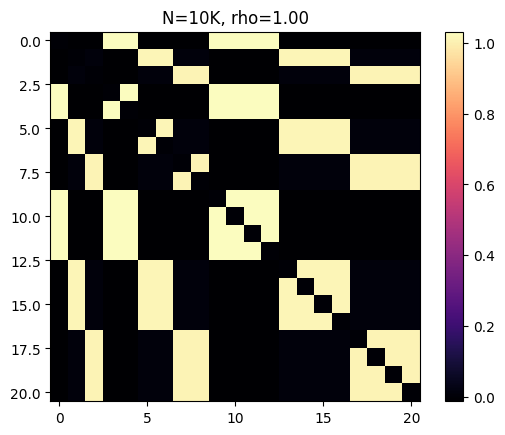

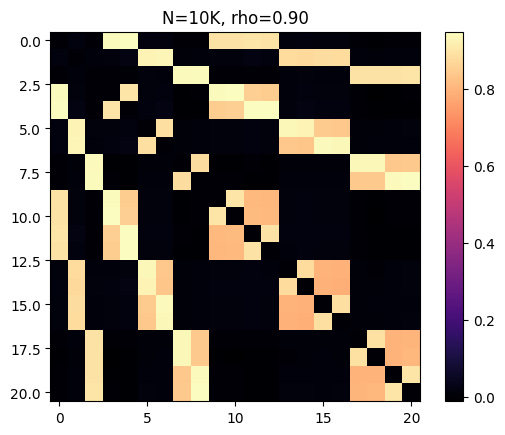

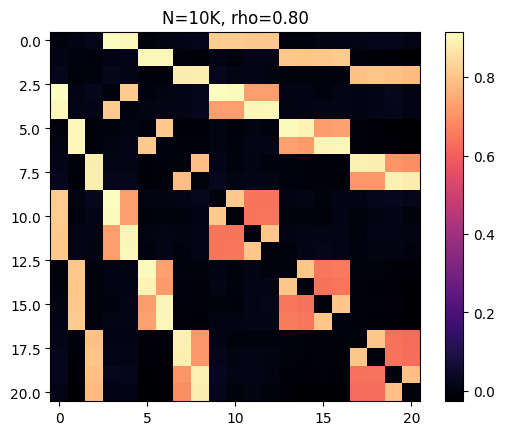

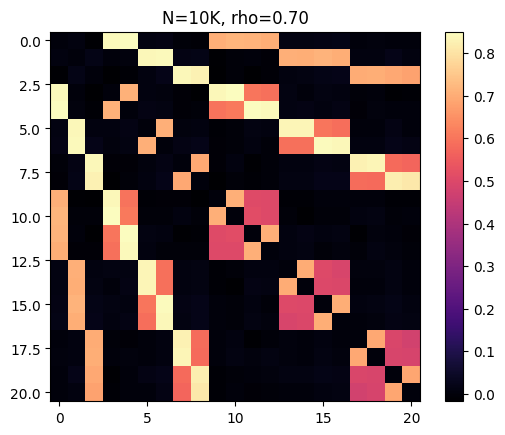

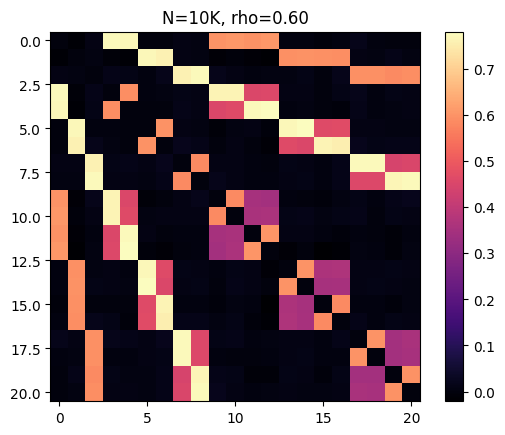

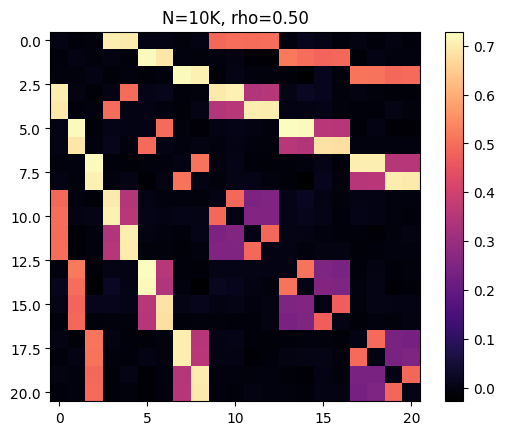

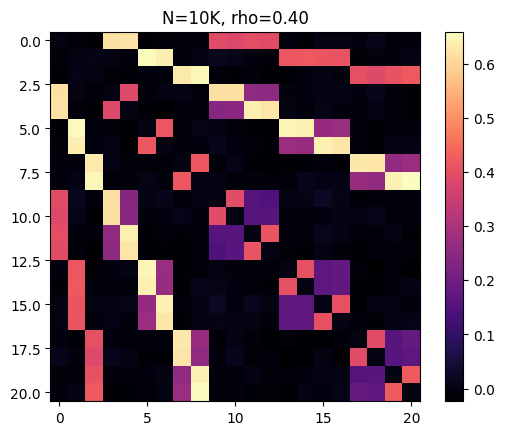

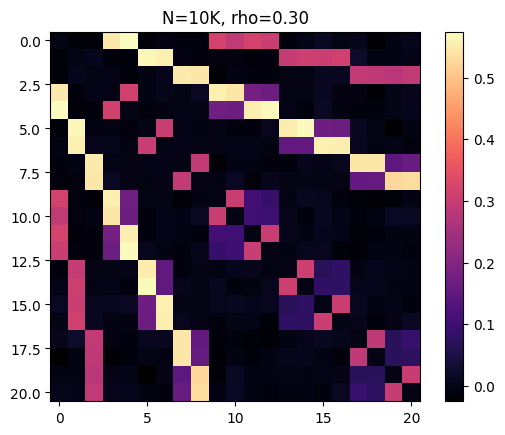

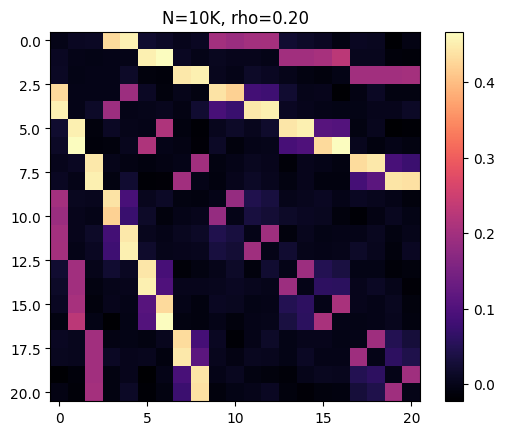

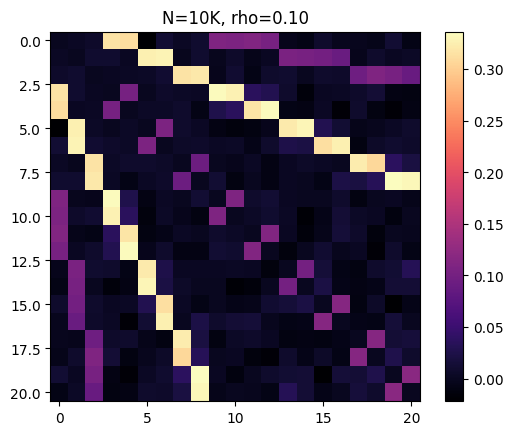

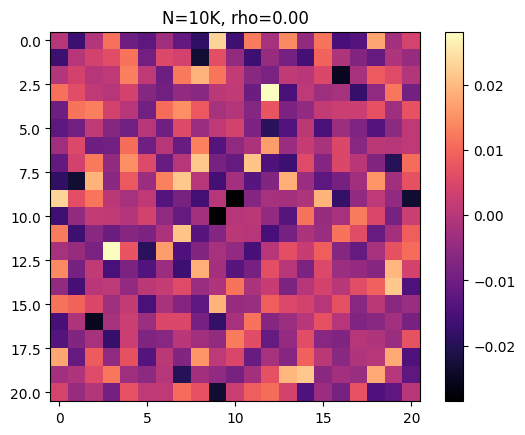

In [7]:
rhos = np.linspace(0.0,1.0,11)[::-1]

for rho in rhos:
    ###stacked_history = get_gaussian_hierarchical_data(N,rho)
    dgp_x = Continuous_HierarchicalNoiseModel_InputDataGenerator('cts_gauss', rho)
    stacked_history = dgp_x.generate_samples(N, True)
    mi_matr = np.cov(stacked_history.T)
    
    if True:
        xd = mi_matr
        if True:
            xd[np.arange(21),np.arange(21)] = 0.0
        # plt.figure(figsize=(10,10))
        plt.title(f"N={N//1000}K, rho={rho:.2f}")
        plt.imshow(xd, cmap='magma')
        plt.colorbar()
        plt.show()

In [8]:
L = 101
rhos = np.linspace(0.0,1.0,L)[::-1]
IP = len(interesting_pairs)
tracking_matrix = np.zeros((L,IP))

for rr,rho in enumerate(rhos):
    print(rho)
    dgp_x = Continuous_HierarchicalNoiseModel_InputDataGenerator('cts_gauss', rho)
    stacked_history = dgp_x.generate_samples(N, True)
    mi_matr = np.cov(stacked_history.T)

    for ii,(i,j) in enumerate(interesting_pairs):
        tracking_matrix[rr,ii] = mi_matr[i,j]
        if ii==0:
            print(mi_matr[i,j])
            print()

1.0
1.0080486254156236

0.99
1.004992621288644

0.98
0.9848262794734227

0.97
1.003749500293703

0.96
0.9720607697317672

0.9500000000000001
0.9689539648123032

0.9400000000000001
0.98188806334553

0.93
0.9565559490797326

0.92
0.9517414136245281

0.91
0.9483178694945504

0.9
0.9695004853646503

0.89
0.9491422593242257

0.88
0.9584715628333345

0.87
0.9612790888049736

0.86
0.9509282260009297

0.85
0.9227481116089329

0.84
0.8934128557671764

0.8300000000000001
0.9087631834617526

0.8200000000000001
0.9147331251208586

0.81
0.8623810076675421

0.8
0.8907396303395165

0.79
0.8682711729876307

0.78
0.860886370716102

0.77
0.8856687995120545

0.76
0.8843520737840356

0.75
0.8630702739128703

0.74
0.8528865712832189

0.73
0.8524489223086795

0.72
0.8466647520396963

0.71
0.8076000598695129

0.7000000000000001
0.8456341148339345

0.6900000000000001
0.8524806430713496

0.68
0.8213704907585577

0.67
0.8346426589034207

0.66
0.8139673283630505

0.65
0.8217938415652534

0.64
0.7917345296699251


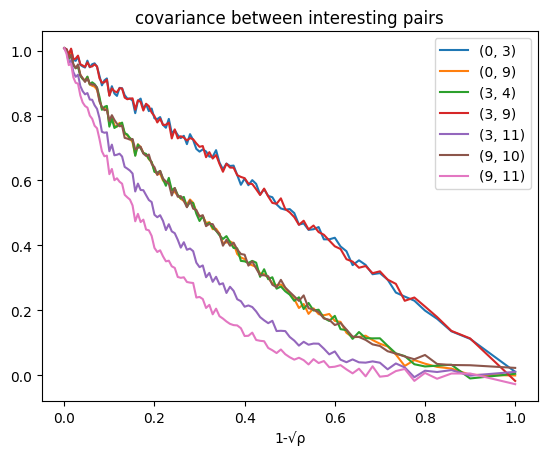

In [9]:
plt.title('covariance between interesting pairs')
for ii,(i,j) in enumerate(interesting_pairs):
#     plt.plot(rhos, tracking_matrix[:,ii], label=str( (i,j) ))
# plt.xlabel("ρ")
    plt.plot(1-np.sqrt(rhos), tracking_matrix[:,ii], label=str( (i,j) ))
plt.xlabel("1-√ρ")
#     plt.plot(1-np.array(rhos), tracking_matrix[:,ii], label=str( (i,j) ))
# plt.xlabel("1-ρ")
plt.legend()
plt.show()

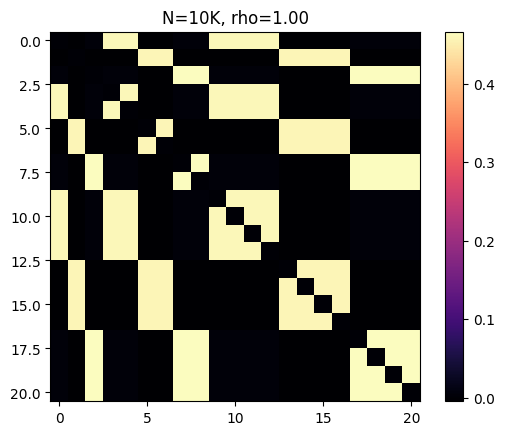

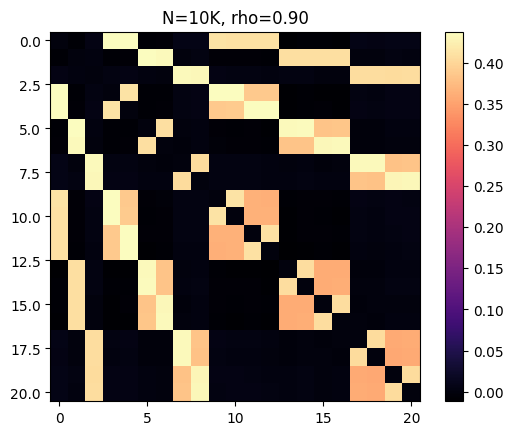

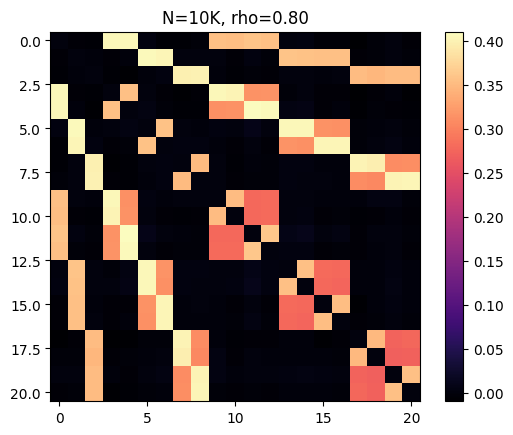

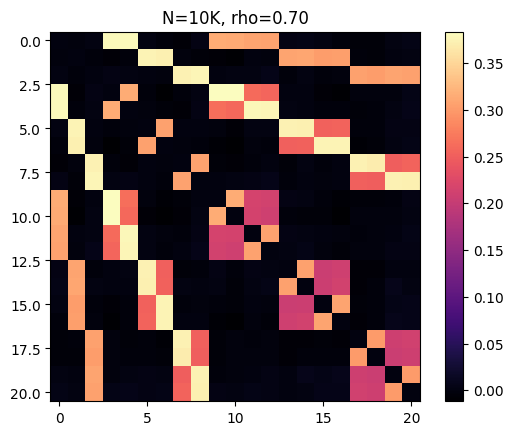

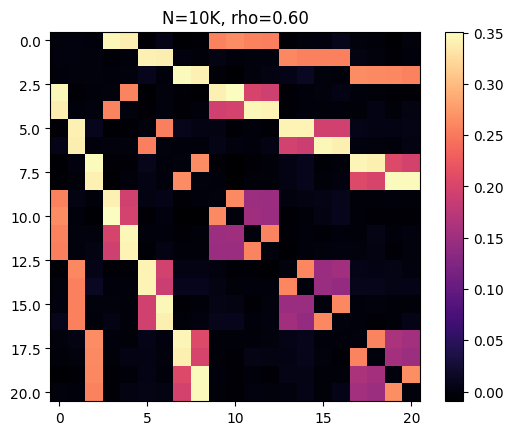

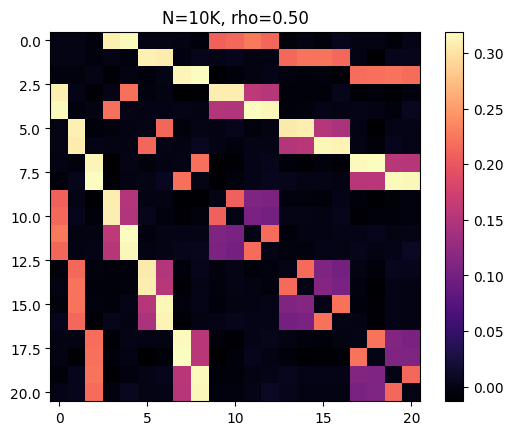

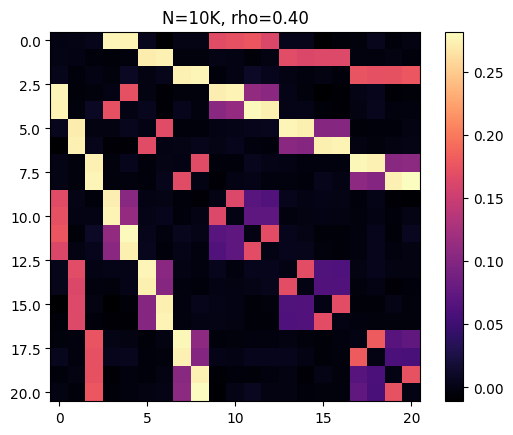

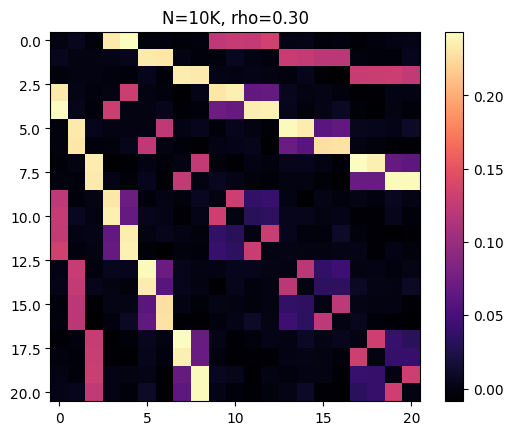

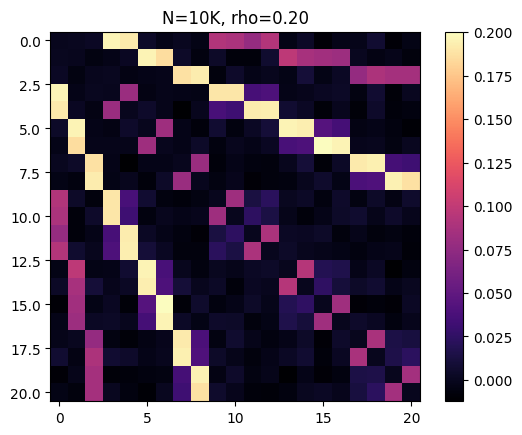

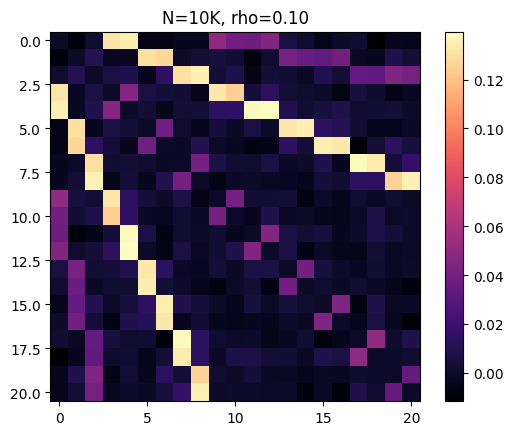

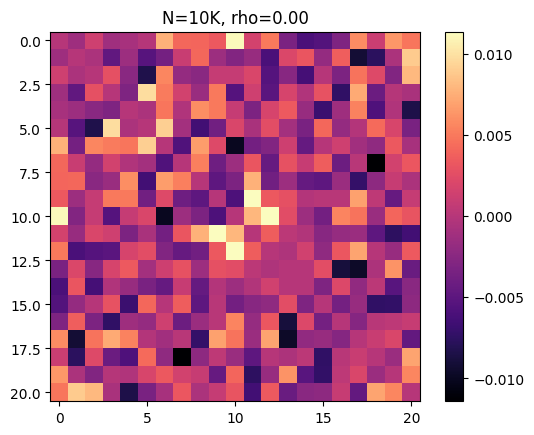

In [10]:
N = 10*1000
rhos = np.linspace(0.0,1.0,11)[::-1]

for rho in rhos:
    ###stacked_history = get_gaussian_hierarchical_data(N,rho)
    ###new_stacked_history = gaussian_copulize(stacked_history)
    dgp_x = Continuous_HierarchicalNoiseModel_InputDataGenerator('cts_unif', rho)
    new_stacked_history = dgp_x.generate_samples(N, True)
    mi_matr = np.cov(new_stacked_history.T)
    
    if True:
        xd = mi_matr
        if True:
            xd[np.arange(21),np.arange(21)] = 0.0
        # plt.figure(figsize=(10,10))
        plt.title(f"N={N//1000}K, rho={rho:.2f}")
        plt.imshow(xd, cmap='magma')
        plt.colorbar()
        plt.show()

In [11]:
L = 101
rhos = np.linspace(0.0,1.0,L)[::-1]
IP = len(interesting_pairs)
tracking_matrix = np.zeros((L,IP))

for rr,rho in enumerate(rhos):
    print(rho)
    ###stacked_history = get_gaussian_hierarchical_data(N,rho)
    ###new_stacked_history = gaussian_copulize(stacked_history)
    dgp_x = Continuous_HierarchicalNoiseModel_InputDataGenerator('cts_unif', rho)
    new_stacked_history = dgp_x.generate_samples(N, True)
    mi_matr = np.cov(new_stacked_history.T)

    for ii,(i,j) in enumerate(interesting_pairs):
        tracking_matrix[rr,ii] = mi_matr[i,j]
        if ii==0:
            print(mi_matr[i,j])
            print()

1.0
0.46262558242771173

0.99
0.4557667063155816

0.98
0.45736334348221314

0.97
0.4553618692957715

0.96
0.46114785060987873

0.9500000000000001
0.4438289322838575

0.9400000000000001
0.45278154588127156

0.93
0.44860812798121874

0.92
0.43529982685297636

0.91
0.44366677014051026

0.9
0.4371998218114483

0.89
0.4289747246219469

0.88
0.4336479419293402

0.87
0.4280410158337459

0.86
0.42061190576461716

0.85
0.41952378223215975

0.84
0.42209289945669193

0.8300000000000001
0.416202512611506

0.8200000000000001
0.4121547969523099

0.81
0.41322986748713036

0.8
0.40287838065039716

0.79
0.40437370303323217

0.78
0.40176865348380875

0.77
0.40053347953138807

0.76
0.38977303815553976

0.75
0.38728194209429245

0.74
0.39622913653163105

0.73
0.3826531189832869

0.72
0.3865593372948894

0.71
0.38285233672777674

0.7000000000000001
0.37950695249195676

0.6900000000000001
0.37174422945287283

0.68
0.36025703526806013

0.67
0.37020667053772743

0.66
0.3684793773328724

0.65
0.360800881691902

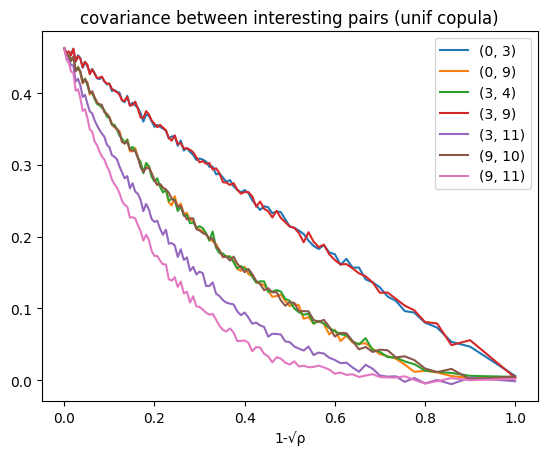

In [12]:
plt.title('covariance between interesting pairs (unif copula)')
for ii,(i,j) in enumerate(interesting_pairs):
#     plt.plot(rhos, tracking_matrix[:,ii], label=str( (i,j) ))
# plt.xlabel("ρ")
    plt.plot(1-np.sqrt(rhos), tracking_matrix[:,ii], label=str( (i,j) ))
plt.xlabel("1-√ρ")
#     plt.plot(1-np.array(rhos), tracking_matrix[:,ii], label=str( (i,j) ))
# plt.xlabel("1-ρ")
plt.legend()
plt.show()

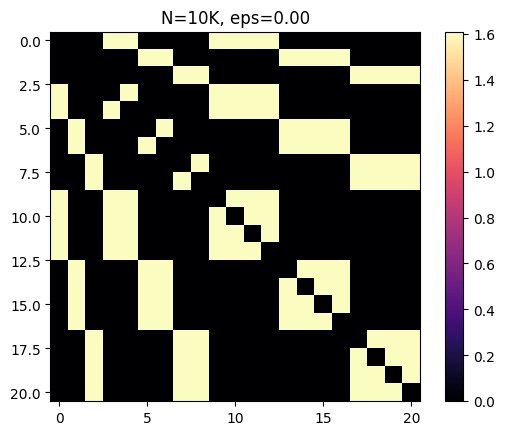

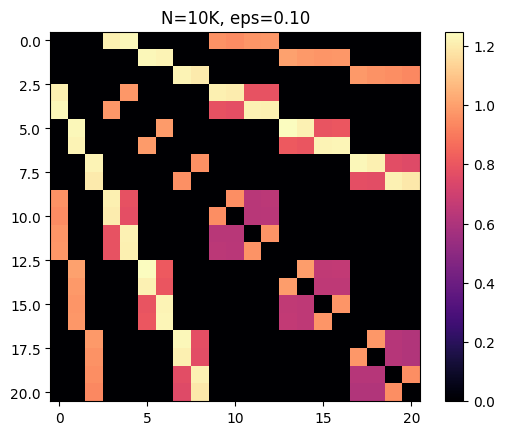

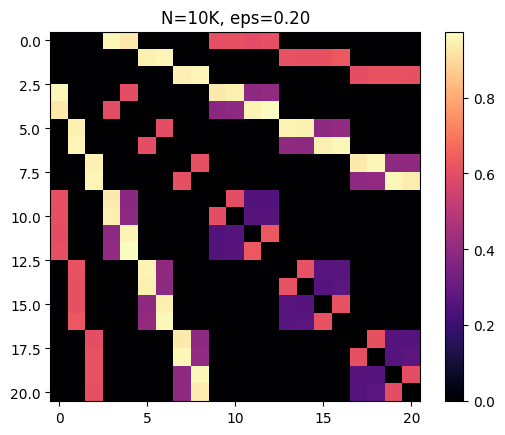

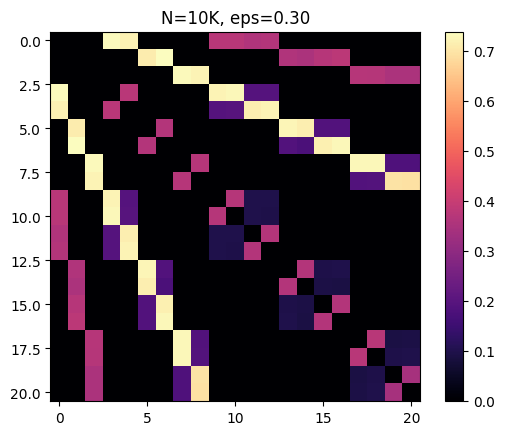

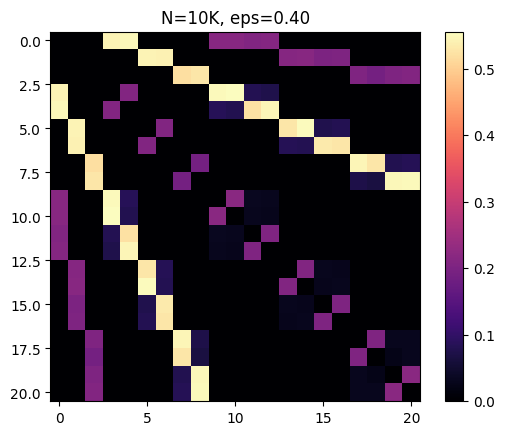

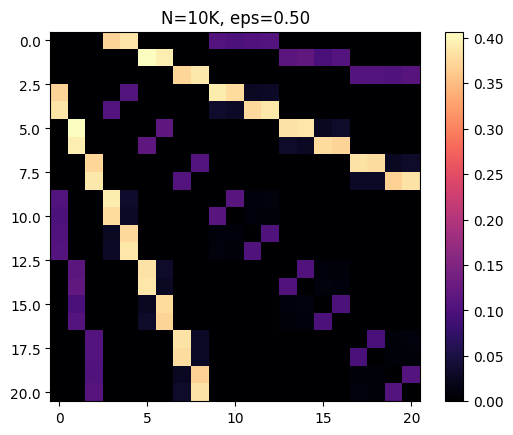

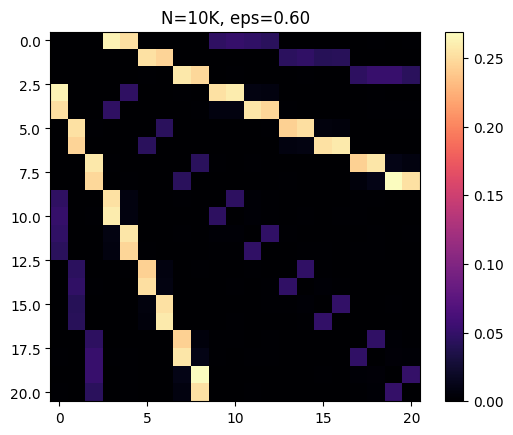

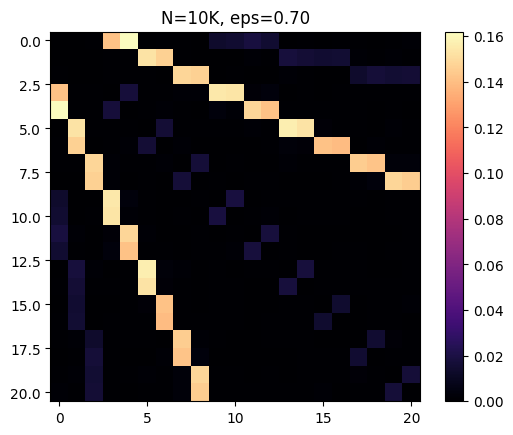

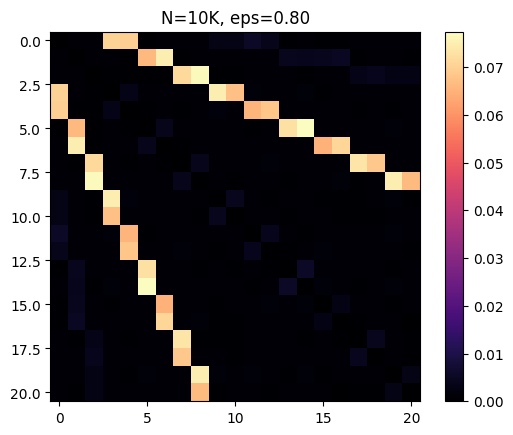

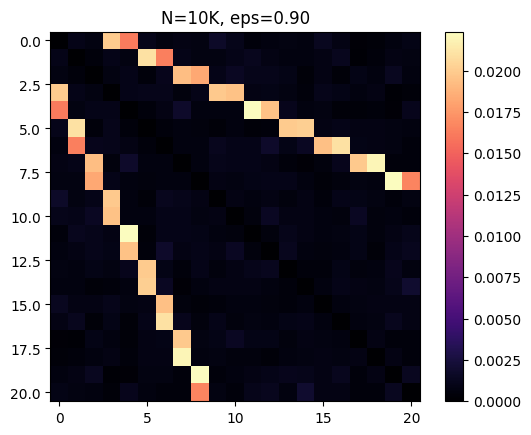

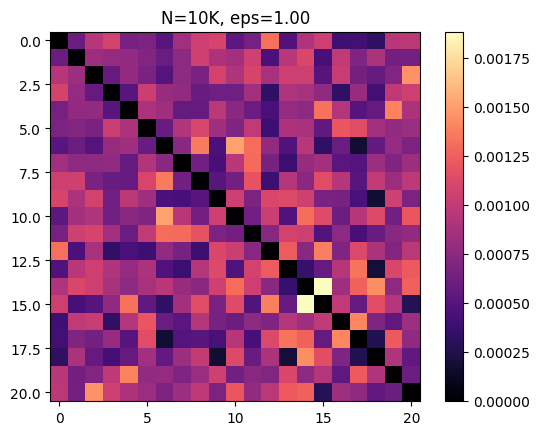

In [22]:
N = 10*1000
I_k = 5
epses = np.linspace(0.0,1.0,11)

for eps in epses:
    ###stacked_history = get_discrete_hierarchical_data(N,I_k,eps)
    dgp_x = Discrete_HierarchicalNoiseModel_InputDataGenerator(I_k, eps)
    stacked_history = dgp_x.generate_samples(N, True)
    mi_matr = full_mi_matrix(stacked_history)

    if True:
        xd = mi_matr
        if True:
            xd[np.arange(21),np.arange(21)] = 0.0
        plt.title(f"N={N//1000}K, eps={eps:.2f}")
        plt.imshow(xd, cmap='magma')
        plt.colorbar()
        plt.show()

In [23]:
I_k=5
# I_k=10
# I_k=2

L = 101
epses = np.linspace(0.0,1.0,L)
IP = len(interesting_pairs)
tracking_matrix = np.zeros((L,IP))

for ee,eps in enumerate(epses):
    print(eps)
    ###stacked_history = get_discrete_hierarchical_data(N,I_k,eps)
    dgp_x = Discrete_HierarchicalNoiseModel_InputDataGenerator(I_k, eps)
    stacked_history = dgp_x.generate_samples(N, True)
    mi_matr = full_mi_matrix(stacked_history)

    for ii,(i,j) in enumerate(interesting_pairs):
        tracking_matrix[ee,ii] = mi_matr[i,j]

0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35000000000000003
0.36
0.37
0.38
0.39
0.4
0.41000000000000003
0.42
0.43
0.44
0.45
0.46
0.47000000000000003
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.5700000000000001
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.6900000000000001
0.7000000000000001
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.8200000000000001
0.8300000000000001
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.9400000000000001
0.9500000000000001
0.96
0.97
0.98
0.99
1.0


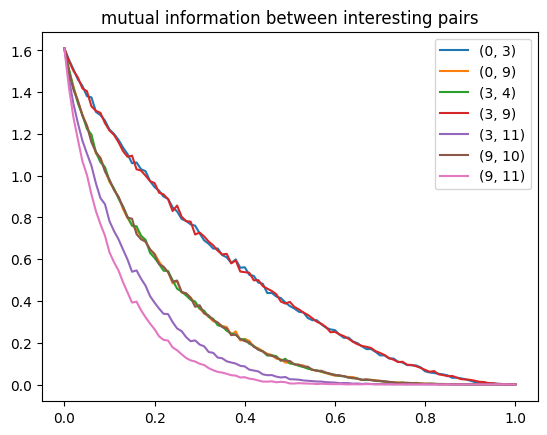

In [24]:
plt.title('mutual information between interesting pairs')
for ii,(i,j) in enumerate(interesting_pairs):
    plt.plot(epses, tracking_matrix[:,ii], label=str( (i,j) ))
plt.legend()
plt.show()